In [73]:
'''
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/LAB_mod_B/Project/Classification
import sys
print(sys.executable)
'''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/LAB_mod_B/Project/Classification
/usr/bin/python3


# Part 0: Importing libraries

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tqdm.notebook import tqdm
import seaborn as sns

from sklearn.decomposition import PCA
import os
from itertools import product
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler

# Part 1: Data

Select the zone of interest

In [ ]:
sel_zone = 'IT_NORD'

In [ ]:
# make directory for saving screenshots
directory_name = f'{sel_zone}_classification_pictures'
try:
    os.mkdir(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{directory_name}' already exists.")
except PermissionError:
    print(f"Permission denied: Unable to create '{directory_name}'.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory 'IT_NORD_classification_pictures' already exists.


## 1.1 Data importing and Merging

In [ ]:
df_features = pd.read_csv(f'{sel_zone}_VAE_input.csv')  # standardized features (input X)
df_labels = pd.read_csv(f'{sel_zone}_classification_input.csv')  # normalized labels (0-1)

df_labels = df_labels[['date_time', 'time', 'ratio', 'wind_installed', 'hydro_installed', 'solar_installed']]
df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['date_time'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)

# merge on timestamp to keep only the ones in common
common = pd.merge(df_features, df_labels, on='date_time', how='inner')
df_labels = common[df_labels.columns]
df_features = common[df_features.columns]

print("Features shape:", df_features.shape)
print("Labels shape:", df_labels.shape)
print("Label columns:", list(df_labels.columns))

Features shape: (8320, 129)
Labels shape: (8320, 6)
Label columns: ['date_time', 'time', 'ratio', 'wind_installed', 'hydro_installed', 'solar_installed']


## 1.2 Define Classes based on Ratio

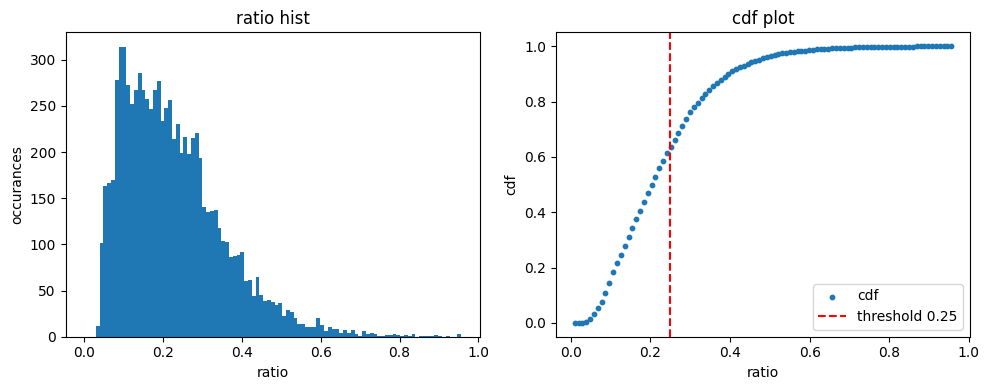

In [ ]:
nbins = 100
thresholds = [0.25]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
hist = ax[0].hist(df_labels['ratio'], bins = np.linspace(0,max(df_labels['ratio']),nbins))
ax[0].set_xlabel('ratio')
ax[0].set_ylabel('occurances')
ax[0].set_title('ratio hist')

freq = hist[0]
cdf = np.cumsum(freq)
cdf = cdf / max(cdf)
x_axis = np.linspace(0,max(df_labels['ratio']),nbins)
x_axis = x_axis[1:]
ax[1].scatter(x_axis, cdf, s = 10, label = 'cdf')
ax[1].set_xlabel('ratio')
ax[1].set_ylabel('cdf')
ax[1].set_title('cdf plot')

for threshold in thresholds:
    ax[1].axvline(x=threshold, color='r', linestyle='--', label =f'threshold {threshold}')
ax[1].legend()

plt.tight_layout()
filename = f'{directory_name}/part1.4_ratio_hist_cdf.png'
plt.savefig(filename)
plt.show()

In [ ]:
class_idx = 1
new_thresholds = [0] + thresholds + [max(df_labels['ratio'])]

df_labels['class'] = np.zeros(len(df_labels.index))

print('class intervals:',new_thresholds)
# Assign class based on interval
for i in range(len(new_thresholds) - 1):
    mask = (df_labels['ratio'] > new_thresholds[i]) & (df_labels['ratio'] <= new_thresholds[i + 1])
    df_labels.loc[mask, 'class'] = class_idx
    class_idx += 1

# Check number of datapoints in each class
all_classes = np.unique(df_labels['class'])
tot = len(df_labels['class'])

for class_ in all_classes:
    occ = np.sum(df_labels['class'] == class_)
    print(f'class {int(class_)} occurs {occ} times: {occ/tot:.2%}')


class intervals: [0, 0.25, 0.9559345076250148]
class 1 occurs 5267 times: 63.31%
class 2 occurs 3053 times: 36.69%


<ipython-input-30-accb7e057990>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labels['class'] = np.zeros(len(df_labels.index))


## 1.3 Preprocess Features

In [ ]:
# backup of timestamp for the plots
df = df_features.copy()
timestamp = pd.to_datetime(df['timestamp'])
timestamp_backup = timestamp.copy()
timestamp = df_labels['class']
timestamp_tensor = torch.tensor(timestamp, dtype = torch.float32)

to_drop = [col for col in df.columns if 'day_' in col or 'month_' in col]
#to_drop = [col for col in df.columns if col.startswith('sin') or col.startswith('cos')]       to keep day and month instead
df = df.drop(columns=to_drop + ['timestamp', 'Unnamed: 0', 'date_time'])

print("Final input feature shape:", df.shape)
df.head()

Final input feature shape: (8320, 90)


,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,cos_dayofyear_t0,...,year_t8,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.227214,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.227214,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.227214,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.227214,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.227214,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222


## 1.4 Dataset Setup and Split

In [ ]:
# Rax input (VAE old input)
X_raw_np = df.values
scaler_input = StandardScaler()                             # rescale input
X_raw_scaled = scaler_input.fit_transform(X_raw_np)
X_raw = torch.tensor(X_raw_scaled, dtype=torch.float32)

df_extra = df_labels.drop(columns=['class', 'date_time', 'ratio'])
X_extra_np = df_extra.values
scaler_extra = StandardScaler()
X_extra_scaled = scaler_extra.fit_transform(X_extra_np)
X_extra = torch.tensor(X_extra_scaled, dtype=torch.float32)

Y = torch.tensor(df_labels['class'].values, dtype=torch.long)

print("X_raw:", X_raw.shape)
print("X_extra:", X_extra.shape)
print("Labels:", Y.shape)

X_raw: torch.Size([8320, 90])
X_extra: torch.Size([8320, 4])
Labels: torch.Size([8320])


In [ ]:
class CombinedDataset(Dataset):
    def __init__(self, X_raw, X_extra, Y):
        self.X_raw = X_raw
        self.X_extra = X_extra
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X_raw[idx], self.X_extra[idx], self.Y[idx]

dataset = CombinedDataset(X_raw, X_extra, Y)
total_size = len(dataset)
train_end = int(0.7 * total_size)                             # 70% train + 15% val + 15% test
val_end = train_end + int(0.15 * total_size)

indices = list(range(total_size))
train_dataset = Subset(dataset, indices[:train_end])
val_dataset = Subset(dataset, indices[train_end:val_end])
test_dataset = Subset(dataset, indices[val_end:])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 5824
Validation size: 1248
Test size: 1248


# Part 2: Classification

## 2.1 Model Definition

In [ ]:
class SimpleClassifier(nn.Module):
  def __init__(self, x_raw_dim, x_extra_dim, hidden_dims, output_dim, dropout_prob = 0.3):
    super(SimpleClassifier, self).__init__()
    input_dim = x_raw_dim + x_extra_dim

    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dims[0]),
        nn.ReLU(),
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_dims[0], hidden_dims[1]),           # two layers
        nn.ReLU(),
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_dims[1], output_dim)
    )

  def forward(self, x_raw, x_extra):
    x = torch.cat((x_raw, x_extra), dim=1)
    return self.net(x)

## 2.2 Training Preparation

In [ ]:
x_raw_dim = X_raw.shape[1]
x_extra_dim = X_extra.shape[1]
output_dim = len(torch.unique(Y))  # number of classes
hidden_dims = [128, 64]

model = SimpleClassifier(x_raw_dim, x_extra_dim, hidden_dims, output_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)                 # shuffle True
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


## 2.3 Training the NN

In [ ]:
num_epochs = 50

# Define the search space
param_grid = {
    'hidden_dims': [[64, 32], [32,16]],
    'lr': [1e-4, 1e-3],
    'batch_size': [64, 128],
    'weight_decay': [1e-2, 1e-3, 1e-4],
    'dropout_prob': [0.05, 0.15, 0.3]
}

# Create all combinations of parameters
param_combinations = list(product(*param_grid.values()))

correct = 0
total = 0

# Best tracking
best_val_accuracy = 0.0
best_model = None
best_params = None
results = []

# Grid search loop
for params in tqdm(param_combinations, desc="Grid Search"):

  hidden_dims, lr, batch_size, weight_decay, dropout_prob = params
  print(f"\nTraining with: hidden_dims={hidden_dims}, lr={lr}, batch_size={batch_size}, weight_decay={weight_decay}, dropout={dropout_prob}")

  # Update loaders with batch size
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)                      # shuffle True
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  # Initialize model, loss, optimizer
  modelNN = SimpleClassifier(
      x_raw_dim = X_raw.shape[1],
      x_extra_dim = X_extra.shape[1],
      hidden_dims = hidden_dims,
      output_dim = len(torch.unique(Y))+1,                                    # this +1?
      dropout_prob=dropout_prob
  ).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(modelNN.parameters(), lr=lr, weight_decay = weight_decay)

  # Training
  for epoch in range(num_epochs):
    modelNN.train()
    for x_raw, x_extra, labels in train_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

      optimizer.zero_grad()
      logits = modelNN(x_raw, x_extra)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()

  # Validation
  modelNN.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for x_raw, x_extra, labels in val_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      _, predicted = torch.max(logits.data, 1)                                                       # .data?
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_accuracy = 100 * correct / total
  print(f"Validation Accuracy: {val_accuracy:.2f}%")

  results.append({
      'params': params,
      'val_accuracy': val_accuracy
  })

  # Save best
  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_model = modelNN
    best_params = {
        'hidden_dims': hidden_dims,
        'lr': lr,
        'batch_size': batch_size,
        'weight_decay': weight_decay,
        'dropout_prob': dropout_prob
    }

print("\n Best Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


Grid Search:   0%|          | 0/72 [00:00<?, ?it/s]


Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.05
Validation Accuracy: 81.97%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.15
Validation Accuracy: 81.97%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.3
Validation Accuracy: 82.37%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001, dropout=0.05
Validation Accuracy: 81.09%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001, dropout=0.15
Validation Accuracy: 82.05%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001, dropout=0.3
Validation Accuracy: 82.13%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.0001, dropout=0.05
Validation Accuracy: 81.89%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.0001, dropout=0.15
Validation Accuracy: 83.49%

Tr

# Part 3: Retraining with best params

Training Epochs:   0%|          | 0/200 [00:00<?, ?it/s]


 Final Validation Accuracy: 82.37%


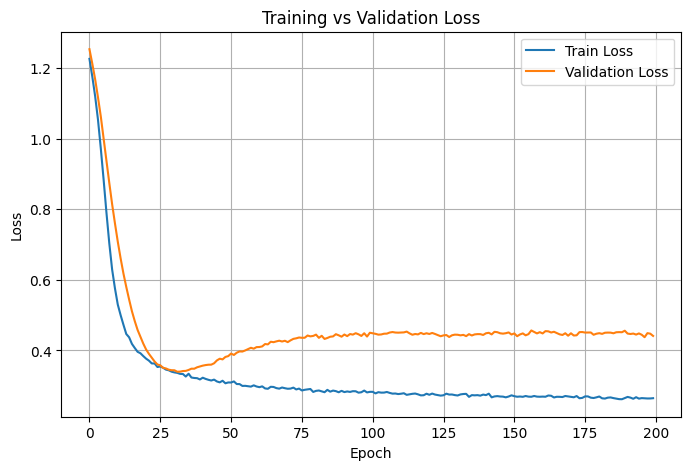

In [ ]:
num_epochs = 200
hidden_dims = best_params['hidden_dims']
lr = best_params['lr']
batch_size = best_params['batch_size']
weight_decay = best_params['weight_decay']
dropout_prob = best_params['dropout_prob']

modelNN = SimpleClassifier(
    x_raw_dim = X_raw.shape[1],
    x_extra_dim = X_extra.shape[1],
    hidden_dims = hidden_dims,
    output_dim = len(torch.unique(Y)) + 1,                                                        # +1?
    dropout_prob = dropout_prob
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelNN.parameters(), lr=lr, weight_decay=weight_decay)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)                     # shuffle True
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

NNlosses = []
val_losses = []

epoch_bar = tqdm(range(num_epochs), desc="Training Epochs")

for epoch in epoch_bar:
    modelNN.train()
    epoch_loss = 0.0

    for x_raw, x_extra, labels in train_loader:
        x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = modelNN(x_raw, x_extra)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_raw.size(0)

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    NNlosses.append(avg_train_loss)

    # Validation loss
    modelNN.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for x_raw, x_extra, labels in val_loader:
            x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

            logits = modelNN(x_raw, x_extra)
            loss = criterion(logits, labels)

            val_loss += loss.item() * x_raw.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    val_accuracy = 100 * correct / total
    epoch_bar.set_postfix(train_loss=avg_train_loss, val_loss=avg_val_loss, val_acc=val_accuracy)

print(f"\n Final Validation Accuracy: {val_accuracy:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), NNlosses, label='Train Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

filename = f'{directory_name}/part3.5_NN_loss.png'
plt.savefig(filename)
plt.show()

# Part 4: Final Results

## 4.1 Confusion Matrix

In [ ]:
def plot_confusion_matrix(data_loader, dataset_name, class_names, directory_name):
  modelNN.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for x_raw, x_extra, labels in data_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      _, predicted = torch.max(logits, 1)
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
  plt.figure(figsize=(5, 4))
  sns.heatmap(
      cm_normalized,
      annot=True,
      fmt=".2f",
      cmap='Blues',
      xticklabels=class_names,
      yticklabels=class_names,
      annot_kws={"size": 14}
  )
  plt.xlabel('Predicted label', fontsize=16)
  plt.ylabel('True label', fontsize=16)
  plt.title(f'{dataset_name} Confusion Matrix', fontsize=18)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.tight_layout()

  filename = f'{directory_name}/conf_matrix_{dataset_name.lower()}.png'
  plt.savefig(filename)
  plt.show()

  print(f"\nClassification Report for {dataset_name} Set:")
  print(classification_report(all_labels, all_preds, target_names=[f"Class {c}" for c in class_names]))

### Confusion Matrix Plots

In [ ]:
class_labels = torch.unique(Y).tolist()
class_names = [str(int(c)) for c in class_labels] # Convert float class labels to strings

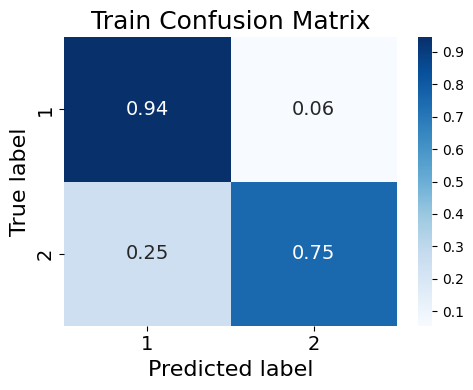


Classification Report for Train Set:
              precision    recall  f1-score   support

     Class 1       0.91      0.94      0.93      4294
     Class 2       0.83      0.75      0.79      1530

    accuracy                           0.89      5824
   macro avg       0.87      0.85      0.86      5824
weighted avg       0.89      0.89      0.89      5824



In [ ]:
plot_confusion_matrix(train_loader, "Train", class_names, directory_name)

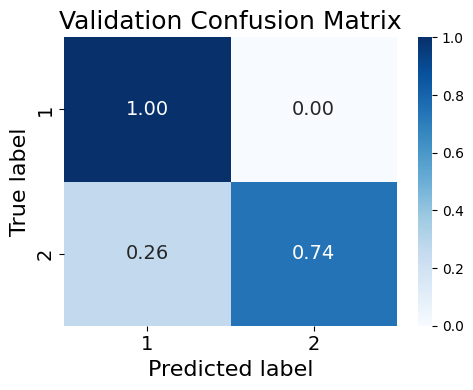


Classification Report for Validation Set:
              precision    recall  f1-score   support

     Class 1       0.65      1.00      0.79       404
     Class 2       1.00      0.74      0.85       844

    accuracy                           0.82      1248
   macro avg       0.82      0.87      0.82      1248
weighted avg       0.89      0.82      0.83      1248



In [ ]:
plot_confusion_matrix(val_loader, "Validation", class_names, directory_name)

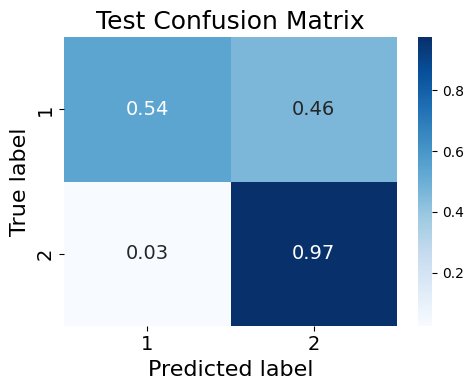


Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 1       0.95      0.54      0.69       569
     Class 2       0.72      0.97      0.83       679

    accuracy                           0.78      1248
   macro avg       0.83      0.76      0.76      1248
weighted avg       0.82      0.78      0.76      1248



In [ ]:
plot_confusion_matrix(test_loader, "Test", class_names, directory_name)

## 4.2 ROC curve

In [ ]:
def plot_roc_curve(data_loader, dataset_name, directory_name):
  modelNN.eval()
  all_labels = []
  all_probs = []

  with torch.no_grad():
    for x_raw, x_extra, labels in data_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      probs = torch.softmax(logits, dim=1)[:, 1]  # probs for class 1

      all_labels.extend(labels.cpu().numpy())
      all_probs.extend(probs.cpu().numpy())

  # Compute ROC curve and AUC
  fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
  roc_auc = auc(fpr, tpr)

  # Plot
  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
  plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
  plt.xlim([-0.01, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate', fontsize=14)
  plt.ylabel('True Positive Rate', fontsize=14)
  plt.title(f'{dataset_name} ROC Curve', fontsize=16)
  plt.legend(loc='lower right', fontsize=12)
  plt.grid(True)
  plt.tight_layout()

  filename = f'{directory_name}/roc_curve_{dataset_name.lower()}.png'
  plt.savefig(filename)
  plt.show()

### ROC Curve Plots

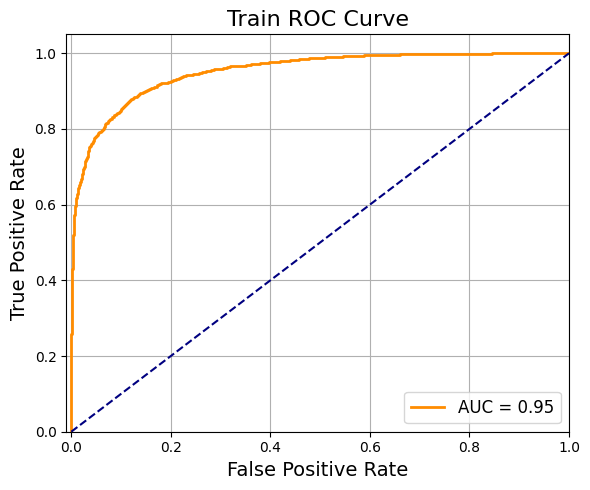

In [ ]:
plot_roc_curve(train_loader, "Train", directory_name)

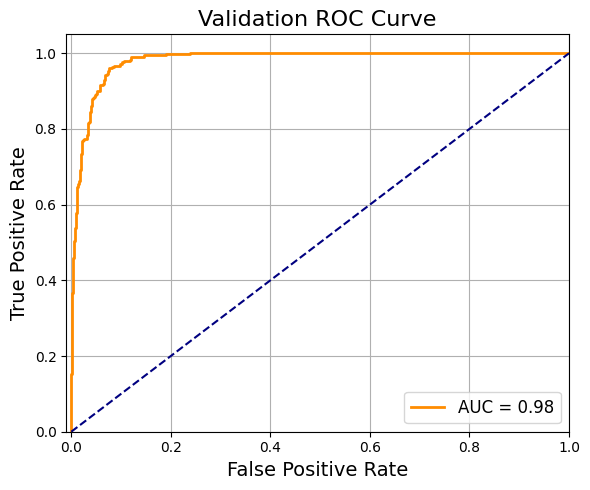

In [ ]:
plot_roc_curve(val_loader, "Validation", directory_name)

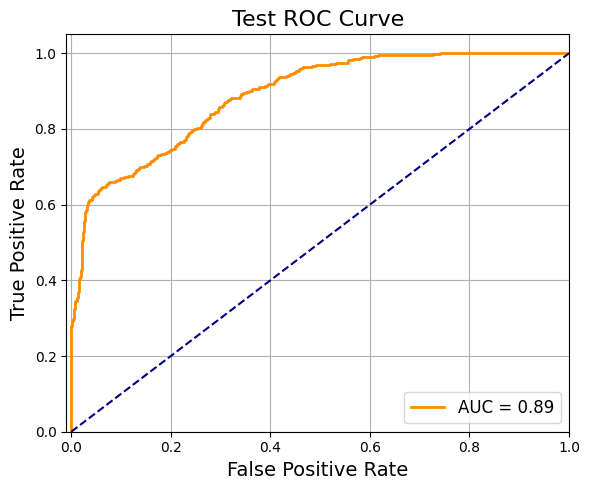

In [ ]:
plot_roc_curve(test_loader, "Test", directory_name)

# Investigating the underperformance of test set

In [ ]:
train_features = df_features[:train_end]
train_labels = df_labels[:train_end]
val_features = df_features[train_end:val_end]
val_labels = df_labels[train_end:val_end]
test_features = df_features[val_end:]
test_labels = df_labels[val_end:]


In [ ]:
sel_columns = ['year_t0','2t_t0','solar_t0','tp_t0','ws_10m_t0','ws_100m_t0','sin_dayofyear_t0','cos_dayofyear_t0']
train_features = train_features[sel_columns]
test_features = test_features[sel_columns]
val_features = val_features[sel_columns]


In [ ]:
summary_train = train_features.describe().T
summary_test = test_features.describe().T

# Combine side by side for easier inspection
comparison = summary_train[['mean', 'std', 'min', 'max']].join(
    summary_test[['mean', 'std', 'min', 'max']], lsuffix='_train', rsuffix='_test'
)

print(comparison)

                  mean_train  std_train  min_train  max_train  mean_test  \
year_t0            -0.524812   0.714540  -1.224855   1.224561   1.224561   
2t_t0              -0.035846   1.025690  -2.106502   2.453705   0.033955   
solar_t0           -0.003410   1.006484  -0.785197   3.012520  -0.142351   
tp_t0              -0.079260   0.891678  -0.546615   7.370886   0.031492   
ws_10m_t0           0.016427   0.994999  -1.747047   6.111022  -0.125324   
ws_100m_t0          0.012782   0.989555  -1.784983   5.578526  -0.147473   
sin_dayofyear_t0    0.017792   0.979955  -1.442140   1.443590  -0.970409   
cos_dayofyear_t0    0.059550   1.010636  -1.496791   1.292049   0.159468   

                      std_test  min_test  max_test  
year_t0           2.221336e-16  1.224561  1.224561  
2t_t0             1.042147e+00 -1.720219  2.196103  
solar_t0          8.808443e-01 -0.785197  2.651984  
tp_t0             1.159941e+00 -0.546615  7.687608  
ws_10m_t0         1.004103e+00 -1.602359  4.239993

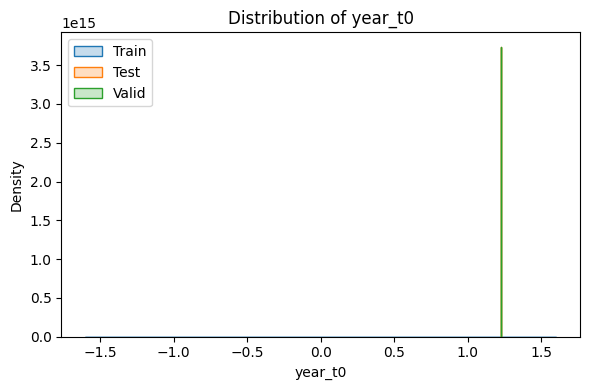

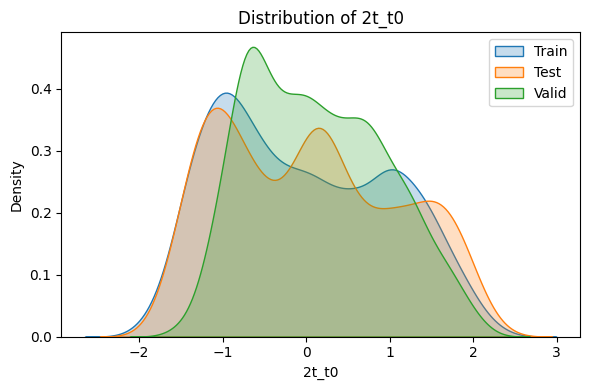

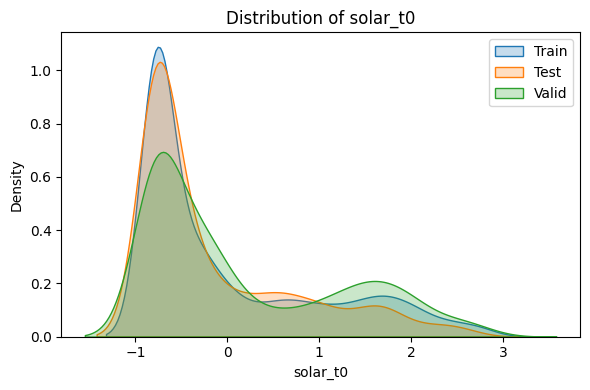

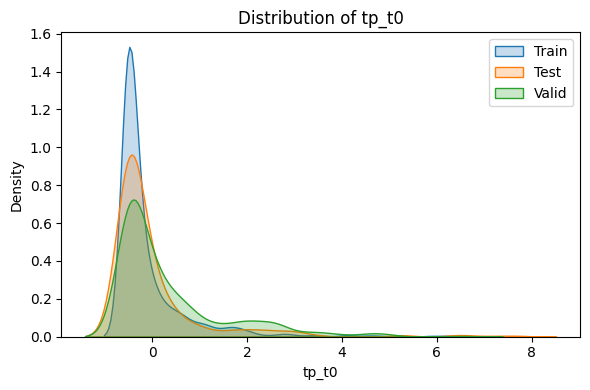

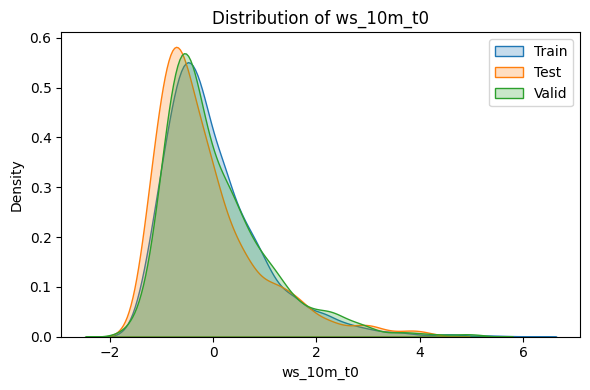

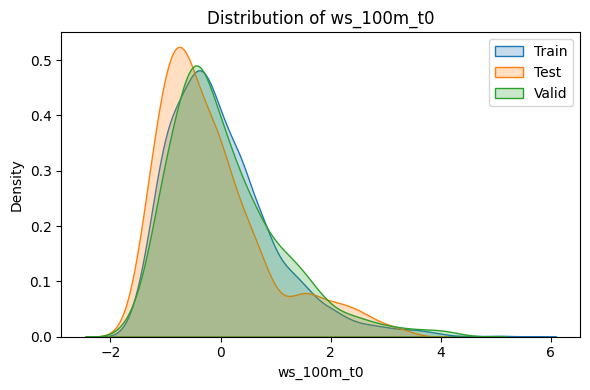

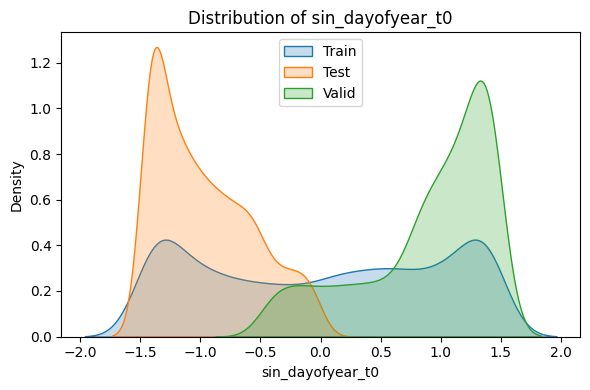

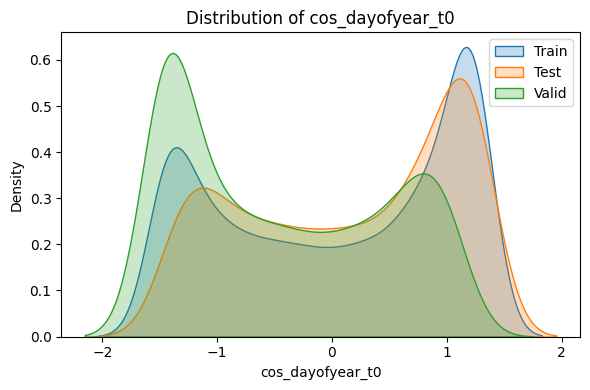

In [ ]:
for column in train_features.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(train_features[column], label='Train', fill=True)
    sns.kdeplot(test_features[column], label='Test', fill=True)
    sns.kdeplot(val_features[column], label = 'Valid', fill = True)
    plt.title(f'Distribution of {column}')
    plt.legend()
    plt.tight_layout()
    plt.show()